In [1]:
from pathlib import Path

import numpy as np
import torch
from matplotlib import pyplot as plt

from e2e.data.loader import SampleLoader
from e2e.data.resampled import ResampledShapePointsDataset
from e2e.data.sample import CrossSectionSample
from e2e.data.loader import EXPERIMENT as EXP

%load_ext autoreload
%autoreload 2

In [2]:
folder = Path("/Users/magnus/repos/WAAM-process-model/outputs/samples")

# get all files in folder
samples = []
fnames = list(folder.glob("*.pickle"))
for filename in fnames:
    samples.append(CrossSectionSample.read_file(filename))
    
sorted_samples = sorted(samples, key=lambda s: s.bead_id)

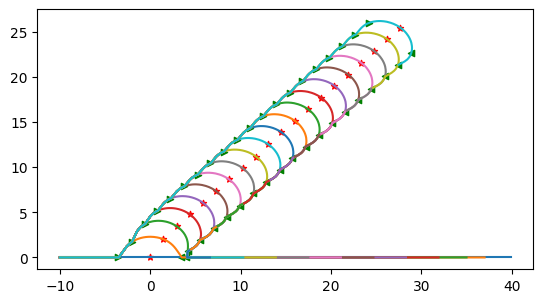

In [3]:
for s in sorted_samples:
    xs = s.slice_based_before.xs
    ys = s.slice_based_before.ys
    base = ys[0]    
    plt.plot(xs[400:900], ys[400:900] - base)
    torch_idx = s.torchposition.global_y_idx
    plt.scatter(xs[torch_idx], ys[torch_idx] - base, marker='*', s=20, c='r')
    
    fp_left_idx  = s.footprint_based.left_idx
    fp_right_idx = s.footprint_based.right_idx
    plt.scatter(xs[fp_left_idx], ys[fp_left_idx] - base, marker='>', s=20, c='g')
    plt.scatter(xs[fp_right_idx], ys[fp_right_idx] - base, marker='<', s=20, c='g')

plt.gca().set_aspect('equal', adjustable='box')
plt.show()

In [13]:
DATASET = Path("/Users/magnus/repos/WAAM-process-model/outputs/samples")
WHICH = [EXP.CONSTANT_EX3, EXP.CONSTANT_EX4, EXP.RANDOM_EX3, EXP.RANDOM_EX5, EXP.SIMULATION_CUBE01]
MIRROR = False
TARGET_LENGTH = 50

loader = SampleLoader(sample_dir=DATASET)
dataset = ResampledShapePointsDataset(mirror=MIRROR, segment_length=TARGET_LENGTH)

In [14]:
cross_section_samples = loader.load(which=WHICH, subset_size=1)

100%|██████████| 20/20 [00:00<00:00, 48.12it/s]


In [15]:
dataset = dataset.create(cross_section_samples)

In [24]:
inpt, trgt, id_, fprint = dataset[0]
trgt[1, :] -= 0.5

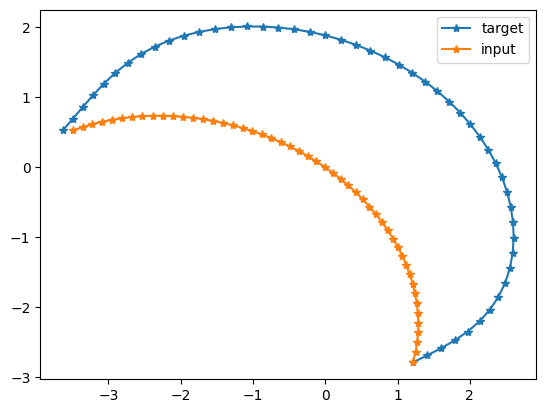

In [25]:
plt.plot(trgt[1, :], trgt[0, :], marker="*", label='target')
plt.plot(inpt[1, :], inpt[0, :], marker="*", label='input')
plt.legend()
plt.show()

In [84]:
closed_curve = torch.cat([inpt, torch.flip(trgt, dims=(1,))], dim=1)
X = closed_curve[1, :]
Z = closed_curve[0, :]

X_next = torch.roll(X, -1)
Z_next = torch.roll(Z, -1)

integral = torch.sum(X_next*Z - Z_next*X)
area = 0.5 * torch.abs(integral)
area

tensor(10.8608)

In [109]:
# for batches
inpt_batch = torch.stack([inpt,inpt,inpt,inpt])
trgt_batch = torch.stack([trgt,trgt,trgt,trgt])

closed_curve_batch = torch.cat([inpt_batch, torch.flip(trgt_batch, dims=(2,))], dim=2)

X_batch = closed_curve_batch[:, 1, :]
Z_batch = closed_curve_batch[:, 0, :]

X_next_batch = torch.roll(X_batch, shifts=(0,-1), dims=(0,1))
Z_next_batch = torch.roll(Z_batch, shifts=(0,-1), dims=(0,1))

integral = torch.sum(X_next_batch * Z_batch - Z_next_batch * X_batch, dim=1)
area = 0.5 * torch.abs(integral)

inpt_batch.shape

torch.Size([4, 2, 50])

In [ ]:
def _calculate_area(inpt_batch: torch.tensor, trgt_bacth: torch.tensor) -> torch.tensor:
    size = torch.Size([-1, 2, 50])
    assert inpt_batch.shape == size and trgt_bacth.shape == size
    
    closed_curve = torch.cat([inpt_batch, torch.flip(trgt_batch, dims=(2,))], dim=2)
    X = closed_curve[:, 1, :]
    Z = closed_curve[:, 0, :]
    X_next = torch.roll(X, shifts=(0,-1), dims=(0,1))
    Z_next = torch.roll(Z, shifts=(0,-1), dims=(0,1))
    integral = torch.sum(X_next * Z - Z_next * X, dim=1)
    area = 0.5 * torch.abs(integral)
    return area
    

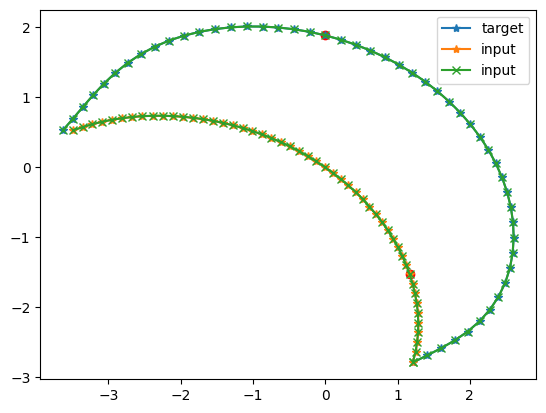

In [82]:
plt.plot(trgt[1, :], trgt[0, :], marker="*", label='target')
plt.plot(inpt[1, :], inpt[0, :], marker="*", label='input')
plt.plot(closed_curve[1, :], closed_curve[0, :], marker="x", label='input')
plt.scatter(closed_curve[1, 40], closed_curve[0, 40], marker="o", c="red")
plt.scatter(closed_curve[1, 80], closed_curve[0, 80], marker="o", c="red")
plt.legend()
plt.show()

In [113]:
def bezier_curve_torch(points, n_points=100):
    """
    Construct a Bezier curve from control points.

    :param points: (Tensor) The control points of the curve. The shape of this
            tensor should be (n_control_points x 2) where the co-ordinates of
            the i-th control point is given by points[i].
    :param n_points: (int) The number of points to construct along the Bezier
            curve.
    
    :return (Tensor) List of coordinates along the path.
    """
    t = torch.linspace(0, 1, steps=n_points).unsqueeze(1)
    n = len(points) - 1
    assert n >= 0

    curve = torch.zeros(n_points, 2)
    for i, point in enumerate(points):
        binom = torch.combinations(n, i) * (1 - t) ** (n - i) * t ** i
        curve += binom * point

    return curve


from scipy.special import comb


def bernstein_poly(i, n, t):
    """
     The Bernstein polynomial of n, i as a function of t
    """

    return comb(n, i) * (t ** (n - i)) * (1 - t) ** i


def bezier_curve(points, nTimes=1000):
    """
       Given a set of control points, return the
       bezier curve defined by the control points.

       points should be a list of lists, or list of tuples
       such as [ [1,1], 
                 [2,3], 
                 [4,5], ..[Xn, Yn] ]
        nTimes is the number of time steps, defaults to 1000

        See http://processingjs.nihongoresources.com/bezierinfo/
    """

    nPoints = len(points)
    xPoints = np.array([p[0] for p in points])
    yPoints = np.array([p[1] for p in points])

    t = np.linspace(0.0, 1.0, nTimes)

    polynomial_array = np.array([bernstein_poly(i, nPoints - 1, t) for i in range(0, nPoints)])

    xvals = np.dot(xPoints, polynomial_array)
    yvals = np.dot(yPoints, polynomial_array)

    return xvals, yvals

In [114]:
points = np.random.rand(4,2)*200
points.shape, trgt.shape

((4, 2), torch.Size([2, 50]))

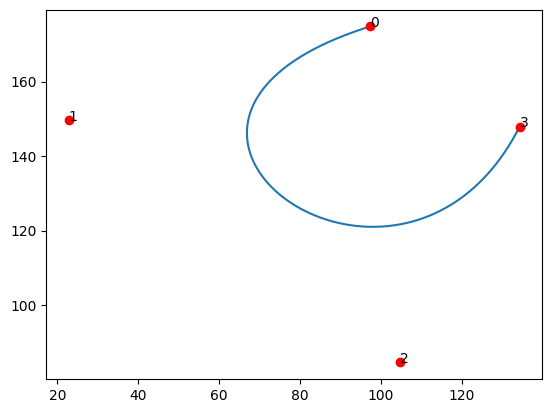

In [117]:
nPoints = 4
points = np.random.rand(nPoints,2)*200
xpoints = [p[0] for p in points]
ypoints = [p[1] for p in points]

xvals, yvals = bezier_curve(points, nTimes=1000)
plt.plot(xvals, yvals)
plt.plot(xpoints, ypoints, "ro")
for nr in range(len(points)):
    plt.text(points[nr][0], points[nr][1], nr)

plt.show()

In [135]:
def bezier3_torch(t: torch.Tensor, w: torch.Tensor) -> torch.Tensor:
    t2 = t * t
    t3 = t2 * t
    mt = 1-t
    mt2 = mt * mt
    mt3 = mt2 * mt
    return w[0]*mt3 + 3*w[1]*mt2*t + 3*w[2]*mt*t2 + w[3]*t3

In [164]:
def bezier3_matrix(t: float, w: torch.Tensor) -> torch.Tensor:
    t_mat = torch.tensor([1, t, t**2, t**3], dtype=torch.float32)
    coeffs = torch.tensor([[1, 0, 0, 0], [-3, 3, 0, 0], [3, -6, 3, 0], [-1, 3, -3, 1]], dtype=torch.float32)
    
    return t_mat @ coeffs @ w

In [170]:
t = torch.linspace(0.0, 1.0, 1000)

xw = torch.tensor(xpoints, dtype=torch.float32)
yw = torch.tensor(ypoints, dtype=torch.float32)

x = bezier3_torch(t, xw)
y = bezier3_torch(t, yw)

P = torch.stack([xw, yw], dim=1)
ps = torch.stack([bezier3_matrix(ti, P) for ti in t])

In [176]:
ps[:, 1]

tensor([174.7691, 174.6933, 174.6173, 174.5410, 174.4645, 174.3877, 174.3107,
        174.2335, 174.1561, 174.0784, 174.0005, 173.9223, 173.8439, 173.7654,
        173.6865, 173.6075, 173.5282, 173.4487, 173.3690, 173.2891, 173.2089,
        173.1286, 173.0480, 172.9672, 172.8862, 172.8049, 172.7235, 172.6418,
        172.5600, 172.4779, 172.3956, 172.3131, 172.2303, 172.1474, 172.0643,
        171.9810, 171.8975, 171.8137, 171.7298, 171.6457, 171.5613, 171.4768,
        171.3921, 171.3072, 171.2220, 171.1367, 171.0513, 170.9655, 170.8796,
        170.7936, 170.7073, 170.6208, 170.5342, 170.4474, 170.3604, 170.2731,
        170.1858, 170.0982, 170.0105, 169.9225, 169.8344, 169.7461, 169.6577,
        169.5690, 169.4802, 169.3913, 169.3021, 169.2128, 169.1232, 169.0336,
        168.9437, 168.8537, 168.7635, 168.6732, 168.5827, 168.4920, 168.4012,
        168.3102, 168.2191, 168.1277, 168.0363, 167.9446, 167.8528, 167.7609,
        167.6688, 167.5765, 167.4841, 167.3915, 167.2988, 167.20

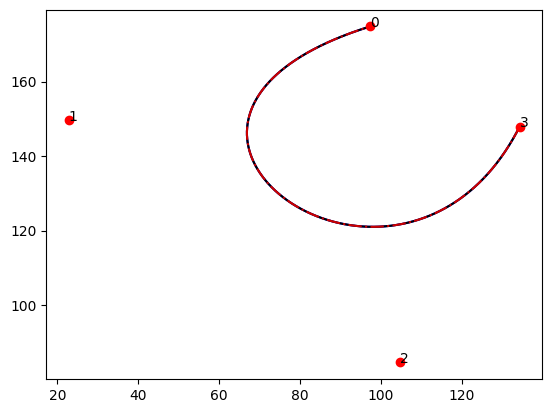

In [178]:
plt.plot(x, y, ls="-", color="blue", label="torch")
plt.plot(ps[:,0], ps[:,1], ls="-", color="black", label="torch matrix")
plt.plot(xvals, yvals, ls="-.", color="red", label="internet (numpy)", alpha=0.8)
plt.plot(xw, yw, "ro")
for nr in range(len(points)):
    plt.text(points[nr][0], points[nr][1], nr)

plt.show()

In [118]:
import scipy
inpt, trgt, id_, fprint = dataset[0]

trgt = trgt.numpy()
# sort trgt along x-values, which are trgt[1, :]
x = trgt[1, :]
y = trgt[0, :]

# Get the sorted indices of array 'x'
idx = np.argsort(x)

# Sort 'x' and 'y' using these indices
x_sorted = x[idx]
y_sorted = y[idx]


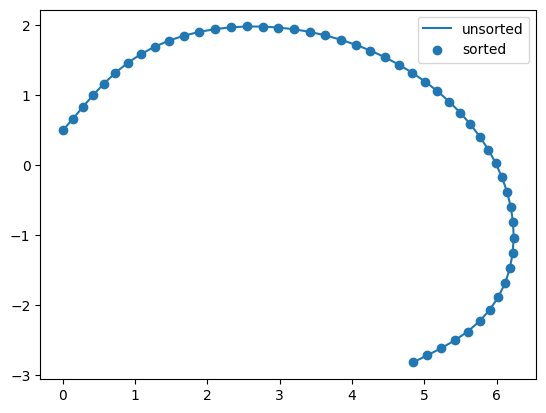

In [119]:
plt.plot(x, y, label="unsorted")
plt.scatter(x_sorted, y_sorted, label="sorted")
plt.legend()

In [131]:
from scipy.interpolate import make_interp_spline

b = make_interp_spline(x_sorted, y_sorted, t=5)

ValueError: Got 1 knots, need at least 54.

In [133]:
type(b)

scipy.interpolate._bsplines.BSpline

In [129]:
b.t.shape

(56,)

In [128]:
b.t.reshape(2,-1)

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.42193943, 0.56954503, 0.72661018, 0.89555013,
        1.07657957, 1.26846635, 1.46922457, 1.67731643, 1.89011729,
        2.10617423, 2.32430768, 2.5435493 , 2.76317143, 2.98240471,
        3.20058084, 3.41706586, 3.63100743, 3.84202242, 4.04949284,
        4.25278044, 4.45122957, 4.64380312],
       [4.83009195, 4.84156847, 5.00934029, 5.03692865, 5.18073368,
        5.23105478, 5.3428483 , 5.42010832, 5.49539804, 5.59919405,
        5.63741159, 5.76287699, 5.76784801, 5.88544226, 5.90609741,
        5.98776865, 6.02517939, 6.0745616 , 6.11820936, 6.1443758 ,
        6.18309164, 6.19548941, 6.23507643, 6.23507643, 6.23507643,
        6.23507643, 6.23507643, 6.23507643]])

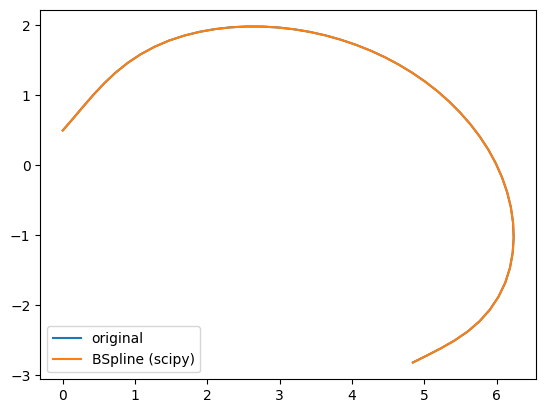

In [127]:
plt.plot(x, y, label="original")
plt.plot(x, b(x), label="BSpline (scipy)")
plt.legend()